# Importing libraries

In [1]:
import sys
github_repo_url = "https://github.com/AnnaEls/HAADF-STEM-image-denoising.git"
!git clone {github_repo_url}
sys.path.append('/content/HAADF-STEM-image-denoising')

Cloning into 'HAADF-STEM-image-denoising'...
remote: Enumerating objects: 1141, done.
remote: Counting objects: 100% (737/737), done.
remote: Compressing objects: 100% (728/728), done.
remote: Total 1141 (delta 364), reused 0 (delta 0), pack-reused 404 (from 2)
Receiving objects: 100% (1141/1141), 96.55 MiB | 12.89 MiB/s, done.
Resolving deltas: 100% (466/466), done.
Updating files: 100% (141/141), done.


In [ ]:
!pip install hyperspy
!pip install atomap

In [3]:
import hyperspy.api as hs
import tifffile
from Utilities.Utils import convert
from Analysis.gaussian_detection_atomap import find_atoms
from Analysis.strain_mapping import estimate_reference_lattice_vectors, estimate_atomic_strain, interpolate_atomic_quantity
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/usr/local/lib/python3.13/dist-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [4]:
def estimate_local_strain(image, separation, ref_x, neighbor_radius_factor, matching_tolerance_factor, minimum_matches, plot = True):
  s = hs.signals.Signal2D(image)
  gaussians = find_atoms(s, separation = separation, plot = True)
  plt.show()
  points_xy = gaussians.atom_positions
  #Estimate lattice vectors from the unstrained region
  v1, v2, six_vectors, a0, points_ref = estimate_reference_lattice_vectors(
        points_xy,
        x_max=ref_x)
  strain_results = estimate_atomic_strain(
      points_xy=points_xy,
      v1=v1,
      v2=v2,
      # First triangular-lattice shell
      neighbor_radius_factor=neighbor_radius_factor,
      # Maximum mismatch to one of the six ideal vectors
      matching_tolerance_factor=matching_tolerance_factor,
      # matched neighbors
      minimum_matches=minimum_matches,
      convert_image_to_cartesian=True)
  if plot:
    # Local strain
    _, _, strain_xx_map = interpolate_atomic_quantity(
        image_shape=image.shape,
        results=strain_results,
        quantity="strain_xx",
        grid_step=1,
        interpolation_method="nearest" # Changed from 'linear' to 'nearest'
        )
    plt.imshow(image, cmap='gray')
    abs_max_strain_overlap = np.nanmax(np.abs(strain_xx_map))
    im = plt.imshow(strain_xx_map * 100, cmap='RdBu_r', vmin=-4.0, vmax=4.0, alpha=0.85)
    plt.axvline(x=270, color='red', linestyle='--', linewidth=2)
    plt.axvline(x=400, color='red', linestyle='--', linewidth=2)
    plt.axis('off')
    plt.colorbar(im, orientation='vertical', label=r'$\varepsilon_{xx}$ (%)')

  return strain_results

In [5]:
SEPARATION = 24
REF_X = 150
NEIGHBOR_RADIUS_FACTOR = 1.40
MATCHING_TOLERANCE_FACTOR = 0.35
MINIMUM_MATCHES = 1

 # Ground truth

## Estimating local strain

(550, 550)

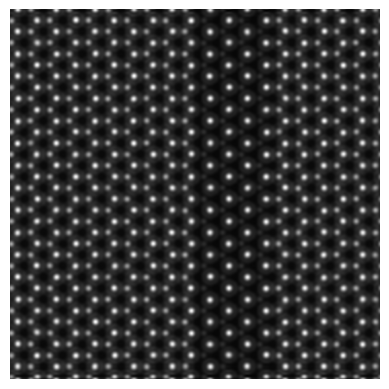

In [6]:
dataset_path = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/"
path_to_clean_image = dataset_path + 'WSe2_WS2_ribbon-ground_truth_interp_0.1_dose_no_noise.tif'
clean_image = convert(tifffile.imread(path_to_clean_image))
plt.imshow(clean_image, cmap='gray'); plt.axis('off')
clean_image.shape

Center of mass:   0%|          | 0/270 [00:00<?, ?it/s]

Gaussian fitting:   0%|          | 0/270 [00:00<?, ?it/s]

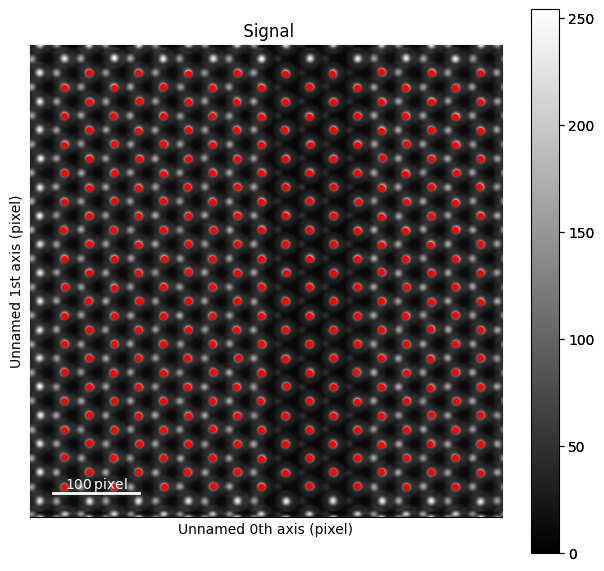

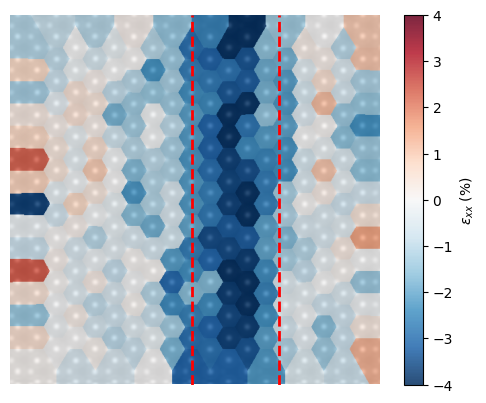

In [7]:
strain_results = estimate_local_strain(clean_image, SEPARATION, REF_X , NEIGHBOR_RADIUS_FACTOR, MATCHING_TOLERANCE_FACTOR, MINIMUM_MATCHES)

## Plotting

In [8]:
strain_gt_df = pd.read_csv("/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/strain_xx_scan_area.csv")
x_scaled_original_gt = np.linspace(0, 550, len(strain_gt_df['epsilon_yy_percentage']))

In [9]:
path_gt_GPA = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/WSe2_WS2_ribbon_strained_GPA_analysis/WSe2_WS2_GT_Exx.dm4"
s_gpa = hs.load(path_gt_GPA)
height, width = s_gpa.data.shape
center_y = height // 2
band_width = height
band_start = max(0, center_y - band_width // 2)
band_end = min(height, center_y + band_width // 2)
averaged_line_profile = np.mean(s_gpa.data[band_start:band_end, :], axis=0)*100

In [10]:
image = clean_image
# Interpolate 'strain_xx' onto a grid
_, _, strain_xx_map = interpolate_atomic_quantity(
    image_shape=image.shape,
    results=strain_results,
    quantity="strain_xx",
    grid_step=1,
    interpolation_method="nearest" # Changed from 'linear' to 'nearest'
)

if np.all(np.isnan(strain_xx_map)):
    print("Warning: The interpolated strain_xx_map contains only NaN values. Cannot create a line scan.")
    print("This suggests that even 'nearest' interpolation could not fill the grid, or 'strain_results' is empty.")
else:

    average_window_size_xx = 300 # Total number of rows to average over
    half_window_xx = average_window_size_xx // 2


    middle_row_index_xx = image.shape[0] // 2


    start_row_xx = max(0, middle_row_index_xx - half_window_xx)
    end_row_xx = min(image.shape[0], middle_row_index_xx + half_window_xx)


    averaged_line_scan_data_xx = np.nanmean(strain_xx_map[start_row_xx:end_row_xx, :], axis=0)


    x_coords_xx = np.arange(image.shape[1])

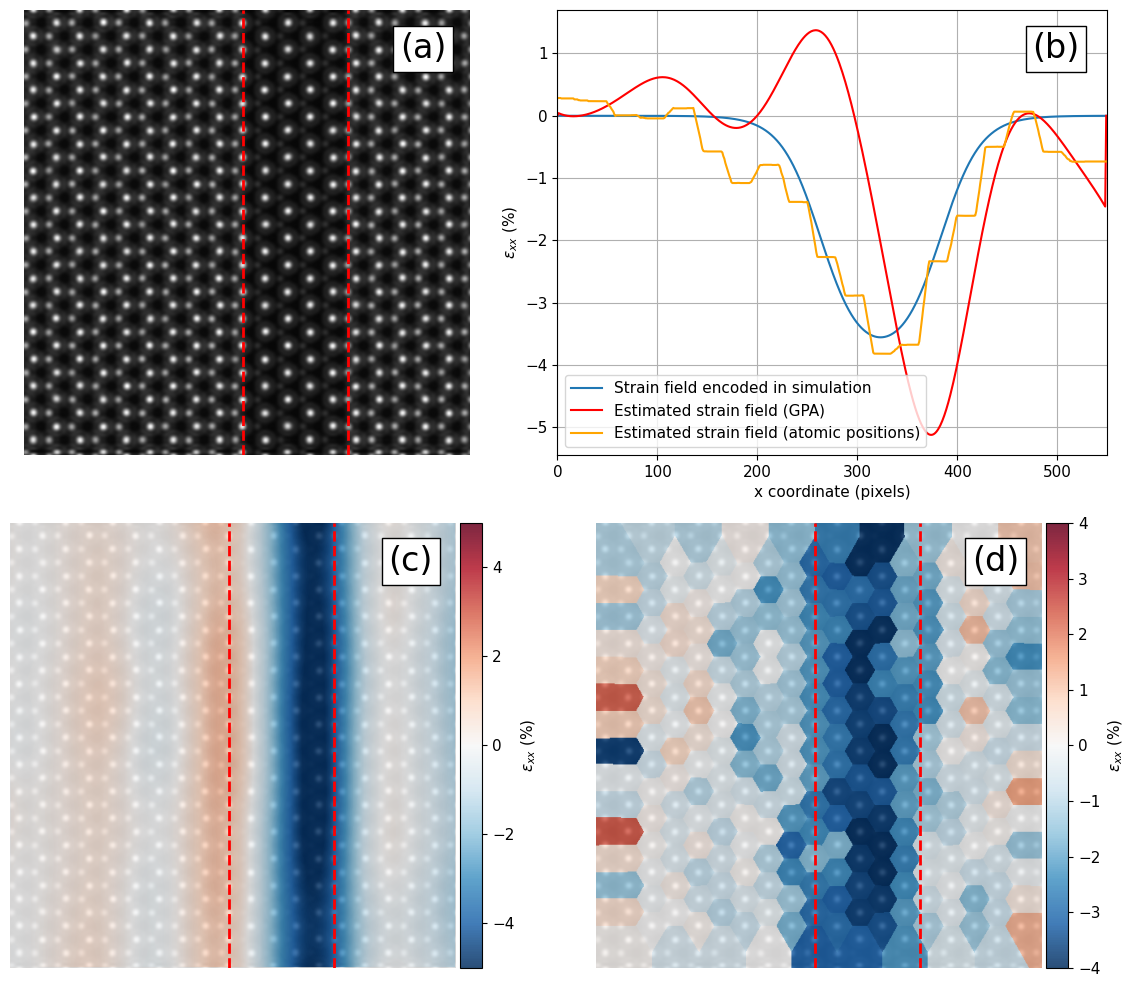

In [11]:
plt.rcParams.update({'font.size': 11})
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec

fig_width = 12  # Adjust as needed
fig_height = 10 # Adjust as needed

# Create a figure and a GridSpec for a 2x2 layout
# Using width_ratios and height_ratios to control subplot sizes
fig = plt.figure(figsize=(fig_width, fig_height))
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1, 1]) # First column 0.7x, second 1.3x; first row 1x, second 1.2x

# Assign subplots to GridSpec cells
ax00 = fig.add_subplot(gs[0, 0]) # Top-Left
ax01 = fig.add_subplot(gs[0, 1]) # Top-Right
ax10 = fig.add_subplot(gs[1, 0]) # Bottom-Left
ax11 = fig.add_subplot(gs[1, 1]) # Bottom-Right

image1 = clean_image
image3 = clean_image
image4 = strain_xx_map

# Ground truth image (Top-Left)
ax00.imshow(image1, cmap='gray')
ax00.axis('off')
ax00.axvline(x=270, color='red', linestyle='--', linewidth=2)
ax00.axvline(x=400, color='red', linestyle='--', linewidth=2)

# Strain profile
ax01.plot(x_scaled_original_gt, strain_gt_df['epsilon_yy_percentage'], label='Strain field encoded in simulation')
ax01.plot(np.arange(len(averaged_line_profile)), averaged_line_profile, label='Estimated strain field (GPA)', color = 'red')
ax01.plot(x_coords_xx[x_coords_xx <= 550], averaged_line_scan_data_xx[x_coords_xx <= 550] * 100, label='Estimated strain field (atomic positions)', color = 'orange')
ax01.set_xlim([0, 550])
ax01.set_xlabel('x coordinate (pixels)')
ax01.set_ylabel(r'$\varepsilon_{xx}$ (%)')
ax01.legend()
ax01.grid(True)


# GPA strain
ax10.imshow(clean_image, cmap='gray')
abs_max_strain_overlap = np.nanmax(np.abs(s_gpa.data))
im = ax10.imshow(s_gpa.data * 100, cmap='RdBu_r', vmin=-5.0, vmax=5.0, alpha=0.85)
ax10.axvline(x=270, color='red', linestyle='--', linewidth=2)
ax10.axvline(x=400, color='red', linestyle='--', linewidth=2)
ax10.axis('off')
divider = make_axes_locatable(ax10)
cax_overlap = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax_overlap, orientation='vertical', label=r'$\varepsilon_{xx}$ (%)')


# Local strain
ax11.imshow(clean_image, cmap='gray')
abs_max_strain_overlap = np.nanmax(np.abs(strain_xx_map))
im = ax11.imshow(strain_xx_map * 100, cmap='RdBu_r', vmin=-4.0, vmax=4.0, alpha=0.85)
ax11.axvline(x=270, color='red', linestyle='--', linewidth=2)
ax11.axvline(x=400, color='red', linestyle='--', linewidth=2)
ax11.axis('off')
divider = make_axes_locatable(ax11)
cax_overlap = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax_overlap, orientation='vertical', label=r'$\varepsilon_{xx}$ (%)')


letters = ["(a)", "(b)", "(c)", "(d)"]
for i, ax in enumerate([ax00, ax01, ax10, ax11]):
    ax.text(0.95, 0.95, letters[i],
            transform=ax.transAxes,
            fontsize=24,
            va='top',
            ha='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))


plt.tight_layout()
plt.show()

# Noisy images

In [ ]:
doses = [1000000.0, 500000.0, 100000.0, 50000.0, 10000.0, 5000.0, 1000.0, 500.0, 100.0]
images_noisy = []
maps_noisy = []
for dose in doses:
  print(f"DOSE: {dose}")
  dataset_path = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/"
  path_to_image = dataset_path + f'WSe2_WS2-jittered_interp_0.1_dose_{dose}.tif'
  image = convert(tifffile.imread(path_to_image))
  images_noisy.append(image)
  strain_results = estimate_local_strain(image, SEPARATION, REF_X , NEIGHBOR_RADIUS_FACTOR, MATCHING_TOLERANCE_FACTOR, MINIMUM_MATCHES)
  _, _, strain_xx_map = interpolate_atomic_quantity(
    image_shape=image.shape,
    results=strain_results,
    quantity="strain_xx",
    grid_step=1,
    interpolation_method="nearest" )
  maps_noisy.append(strain_xx_map)


# Pinto

In [ ]:
doses = [1000000.0, 500000.0, 100000.0, 50000.0, 10000.0, 5000.0, 1000.0, 500.0, 100.0]
images_pinto = []
maps_pinto = []
for dose in doses:
  print(f"DOSE: {dose}")
  dataset_path = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/denoised_pinto/"
  path_to_image = dataset_path + f'WSe2_WS2-jittered_interp_0.1_dose_{dose}_denoised_pinto.tif'
  image = convert(tifffile.imread(path_to_image))
  images_pinto.append(image)
  strain_results = estimate_local_strain(image, SEPARATION, REF_X , NEIGHBOR_RADIUS_FACTOR, MATCHING_TOLERANCE_FACTOR, MINIMUM_MATCHES)
  plt.show()
  _, _, strain_xx_map = interpolate_atomic_quantity(
    image_shape=image.shape,
    results=strain_results,
    quantity="strain_xx",
    grid_step=1,
    interpolation_method="nearest" )
  maps_pinto.append(strain_xx_map)

# Hybrid

In [ ]:
doses = [1000000.0, 500000.0, 100000.0, 50000.0, 10000.0, 5000.0, 1000.0, 500.0, 100.0]
images_hybrid = []
maps_hybrid = []
for dose in doses:
  print(f"DOSE: {dose}")
  dataset_path = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/denoised_hybrid/"
  path_to_image = dataset_path + f'WSe2_WS2-jittered_interp_0.1_dose_{dose}_denoised_hybrid.tif'
  image = convert(tifffile.imread(path_to_image))
  images_hybrid.append(image)
  strain_results = estimate_local_strain(image, SEPARATION, REF_X , NEIGHBOR_RADIUS_FACTOR, MATCHING_TOLERANCE_FACTOR, MINIMUM_MATCHES)
  plt.show()
  _, _, strain_xx_map = interpolate_atomic_quantity(
    image_shape=image.shape,
    results=strain_results,
    quantity="strain_xx",
    grid_step=1,
    interpolation_method="nearest" )
  maps_hybrid.append(strain_xx_map)

# Lobato

In [ ]:
doses = [1000000.0, 500000.0, 100000.0, 50000.0, 10000.0, 5000.0, 1000.0, 500.0, 100.0]
images_lobato = []
maps_lobato = []
for dose in doses:
  print(f"DOSE: {dose}")
  dataset_path = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/denoised_lobato/"
  path_to_image = dataset_path + f'WSe2_WS2-jittered_interp_0.1_dose_{dose}_restored_sfr_hrstem.tif'
  image = convert(tifffile.imread(path_to_image))
  images_lobato.append(image)
  strain_results = estimate_local_strain(image, SEPARATION, REF_X , NEIGHBOR_RADIUS_FACTOR, MATCHING_TOLERANCE_FACTOR, MINIMUM_MATCHES)
  plt.show()
  _, _, strain_xx_map = interpolate_atomic_quantity(
    image_shape=image.shape,
    results=strain_results,
    quantity="strain_xx",
    grid_step=1,
    interpolation_method="nearest" )
  maps_lobato.append(strain_xx_map)

# UNIT

In [ ]:
doses = [1000000.0, 500000.0, 100000.0, 50000.0, 10000.0, 5000.0, 1000.0, 500.0, 100.0]
images_unit = []
maps_unit = []
for dose in doses:
  print(f"DOSE: {dose}")
  dataset_path = "/content/HAADF-STEM-image-denoising/Datasets/DATASET_WSE2_WS2_strained_ribbon/denoised_unit/"
  path_to_image = dataset_path + f'WSe2_WS2-jittered_interp_0.1_dose_{dose}_unit.tif'
  image = convert(tifffile.imread(path_to_image))
  images_unit.append(image)
  strain_results = estimate_local_strain(image, SEPARATION, REF_X , NEIGHBOR_RADIUS_FACTOR, MATCHING_TOLERANCE_FACTOR, MINIMUM_MATCHES)
  plt.show()
  _, _, strain_xx_map = interpolate_atomic_quantity(
    image_shape=image.shape,
    results=strain_results,
    quantity="strain_xx",
    grid_step=1,
    interpolation_method="nearest" )
  maps_unit.append(strain_xx_map)

# Plots

In [ ]:
for k, dose in enumerate(doses):
  print(f"DOSE: {dose}")
  imgs = [images_noisy[k], images_hybrid[k], images_lobato[k], images_pinto[k], images_unit[k]]
  maps = [maps_noisy[k], maps_hybrid[k], maps_lobato[k], maps_pinto[k], maps_unit[k]]
  titles = ["Noisy", "Hybrid","Lobato", "Pinto", "UNIT"]
  letters = ["(a)", "(b)", "(c)", "(d)", "(e)"]
  letters_maps = ["(f)", "(g)", "(h)", "(i)", "(j)"]

  n = len(imgs) # Set n to the actual number of image sets (5)
  sub = 2
  fig = plt.figure(figsize=(5*(n + 0.5), 5*sub),constrained_layout=True)
  fig.set_constrained_layout_pads(w_pad=0.15)
  gs = fig.add_gridspec(sub, n + 1, width_ratios=[1]*n + [0.025]) # n+1 columns, last one for colorbar

  ax_imgs = [fig.add_subplot(gs[0, idx]) for idx in range(n)]
  ax_maps = [fig.add_subplot(gs[1, idx]) for idx in range(n)]

  for idx in range(n):
      ax_img = ax_imgs[idx]
      im_img = ax_img.imshow(
          imgs[idx],
          cmap="gray")
      ax_img.axvline(x=270, color='red', linestyle='--', linewidth=2)
      ax_img.axvline(x=400, color='red', linestyle='--', linewidth=2)
      ax_img.axis("off")

      ax_map = ax_maps[idx]
      im_map = ax_map.imshow(maps[idx] * 100, cmap='RdBu_r', vmin=-4.0, vmax=4.0)
      ax_map.axvline(x=270, color='red', linestyle='--', linewidth=2)
      ax_map.axvline(x=400, color='red', linestyle='--', linewidth=2)
      ax_map.axis('off')

      # Loop only for the actual number of images
      for i, ax in enumerate(ax_imgs):
        ax.text(0.015, 0.95, titles[i],
                transform=ax.transAxes,
                fontsize=28,
                va='top',
                ha='left',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))# Add colorbar to the last column, spanning both rows

        ax.text(0.95, 0.95, letters[i],
                transform=ax.transAxes,
                fontsize=28,
                va='top',
                ha='right',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))# Add colorbar to the last column, spanning both rows


      for i, ax in enumerate(ax_maps):
          ax.text(0.95, 0.95, letters_maps[i],
                transform=ax.transAxes,
                fontsize=28,
                va='top',
                ha='right',
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.2'))# Add colorbar to the last column, spanning both rows


  cax = fig.add_subplot(gs[1, -1])
  fig.colorbar(im_map, cax=cax, orientation='vertical', label=r'$\varepsilon_{xx}$ (%)')
  plt.show()